In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the f1 data-set
df = pd.read_csv("../data/processed/laps_2023.csv")
print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (11255, 33)


In [3]:
pd.set_option("display.max_columns", None)
df.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,RaceName,Year
0,0 days 01:04:15.902000,VER,1,0 days 00:01:39.019000,1.0,1.0,NaN,NaN,NaN,0 days 00:00:42.414000,0 days 00:00:23.842000,NaN,0 days 01:03:52.119000,0 days 01:04:16.010000,232.0,231.0,278.0,252.0,False,SOFT,4.0,False,Red Bull Racing,0 days 01:02:36.652000,NaN,12,1.0,NaN,NaN,False,False,Bahrain,2023
1,0 days 01:05:53.876000,VER,1,0 days 00:01:37.974000,2.0,1.0,NaN,NaN,0 days 00:00:31.342000,0 days 00:00:42.504000,0 days 00:00:24.128000,0 days 01:04:47.303000,0 days 01:05:29.807000,0 days 01:05:53.935000,227.0,238.0,278.0,288.0,True,SOFT,5.0,False,Red Bull Racing,0 days 01:04:15.902000,NaN,12,1.0,NaN,NaN,False,True,Bahrain,2023
2,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,NaN,NaN,0 days 00:00:31.388000,0 days 00:00:42.469000,0 days 00:00:24.149000,0 days 01:06:25.323000,0 days 01:07:07.792000,0 days 01:07:31.941000,227.0,238.0,278.0,287.0,False,SOFT,6.0,False,Red Bull Racing,0 days 01:05:53.876000,NaN,1,1.0,NaN,NaN,False,True,Bahrain,2023
3,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,NaN,NaN,0 days 00:00:31.271000,0 days 00:00:42.642000,0 days 00:00:24.063000,0 days 01:08:03.212000,0 days 01:08:45.854000,0 days 01:09:09.917000,228.0,238.0,278.0,289.0,False,SOFT,7.0,False,Red Bull Racing,0 days 01:07:31.882000,NaN,1,1.0,NaN,NaN,False,True,Bahrain,2023
4,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,NaN,NaN,0 days 00:00:31.244000,0 days 00:00:42.724000,0 days 00:00:24.067000,0 days 01:09:41.161000,0 days 01:10:23.885000,0 days 01:10:47.952000,228.0,239.0,278.0,290.0,False,SOFT,8.0,False,Red Bull Racing,0 days 01:09:09.858000,NaN,1,1.0,NaN,NaN,False,True,Bahrain,2023


In [4]:
print(df.dtypes)

Time                   object
Driver                 object
DriverNumber            int64
LapTime                object
LapNumber             float64
Stint                 float64
PitOutTime             object
PitInTime              object
Sector1Time            object
Sector2Time            object
Sector3Time            object
Sector1SessionTime     object
Sector2SessionTime     object
Sector3SessionTime     object
SpeedI1               float64
SpeedI2               float64
SpeedFL               float64
SpeedST               float64
IsPersonalBest         object
Compound               object
TyreLife              float64
FreshTyre                bool
Team                   object
LapStartTime           object
LapStartDate          float64
TrackStatus             int64
Position              float64
Deleted               float64
DeletedReason         float64
FastF1Generated          bool
IsAccurate               bool
RaceName               object
Year                    int64
dtype: obj

#### Observations:
- Most of the time-related features are stored as objects(text) and IsPersonalBest feature stored as an object, it should be a bool

- -----------------------------------------------------------------------------------------------------------------------------------------

In [5]:
# Checking missing values
missing = df.isnull().sum()
missing_pct = round((missing /len(df)) * 100, 3)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct(%)": missing_pct
}).sort_values("missing_pct(%)", ascending = False)

print(missing_df[missing_df["missing_count"]>0])

                    missing_count  missing_pct(%)
LapStartDate                11255         100.000
Deleted                     11255         100.000
DeletedReason               11255         100.000
PitOutTime                  10884          96.704
PitInTime                   10878          96.650
SpeedFL                       403           3.581
Sector1SessionTime            252           2.239
Sector1Time                   231           2.052
LapTime                       166           1.475
Sector3Time                    90           0.800
Sector3SessionTime             90           0.800
SpeedST                        27           0.240
SpeedI2                        26           0.231
Position                       26           0.231
SpeedI1                        26           0.231
Sector2SessionTime             26           0.231
Sector2Time                    26           0.231
IsPersonalBest                 23           0.204



- The dataset shows varying levels of missingness across features. Several columns (LapStartDate, Deleted, DeletedReason) contain 100% missing values and will be removed as they provide no useful information.

- Pit-related variables such as PitInTime and PitOutTime have over 96% missing values. However, this missingness is not random—it reflects the fact that pit stops occur only during specific laps. Therefore, these features will be used to engineer a binary indicator for pit stop events rather than being discarded.

- Most performance-related features (lap time, sector times, and speed metrics) have very low missingness (<5%), making them reliable for modeling. These can be handled using simple imputation techniques without significantly affecting model performance.
Overall, the dataset is dominated by non-pit laps, which should be considered when designing models for optimal pit strategy.



In [6]:
print(df[["LapStartDate", "Deleted", "DeletedReason"]].isnull().sum())

LapStartDate     11255
Deleted          11255
DeletedReason    11255
dtype: int64


In [7]:
# Checking the duplicate values 
df.duplicated().sum()
if df.duplicated().sum() == 0:
    print("No duplicates")

No duplicates


- No duplicate rows were found, confirming that each of the 11255 records represent a unique observation. This ensure our analysis won't be skewed by repeated entires.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11255 entries, 0 to 11254
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time                11255 non-null  object 
 1   Driver              11255 non-null  object 
 2   DriverNumber        11255 non-null  int64  
 3   LapTime             11089 non-null  object 
 4   LapNumber           11255 non-null  float64
 5   Stint               11255 non-null  float64
 6   PitOutTime          371 non-null    object 
 7   PitInTime           377 non-null    object 
 8   Sector1Time         11024 non-null  object 
 9   Sector2Time         11229 non-null  object 
 10  Sector3Time         11165 non-null  object 
 11  Sector1SessionTime  11003 non-null  object 
 12  Sector2SessionTime  11229 non-null  object 
 13  Sector3SessionTime  11165 non-null  object 
 14  SpeedI1             11229 non-null  float64
 15  SpeedI2             11229 non-null  float64
 16  Spee

- The dataset consists of 11,255 observations and 33 features, providing a moderately sized dataset suitable for machine learning applications. The features include a mix of numerical, categorical, boolean, and time-based variables.
  
- Several time-related features (eg LapTime, sector times, and session times) are currently stored as object types and will require conversion into numerical formats (such as seconds) for proper analysis.

- The IsPersonalBest feature is currently stored as an object type, although it represents a boolean condition. This indicates inconsistent data typing, and the column will be converted to a proper boolean format for efficient processing and modeling.

- The dataset also contains missing values, with some columns (eg. LapStartDate, Deleted, DeletedReason) being entirely empty and therefore candidates for removal.

- Pit-related features (PitInTime, PitOutTime) show high missingness, which is structurally meaningful as pit stops occur only during specific laps.

- Key numerical features such as lap number, tyre life, stint, and speed metrics are well-populated and are expected to be highly informative for modeling.

- Categorical variables such as driver, team, tyre compound, and race name will require encoding before use in machine learning models.

- Importantly, the dataset includes domain-relevant features such as tyre life, compound type, and stint number, which are critical for analyzing tyre degradation and optimizing pit stop strategies.

Additionally, the presence of an accuracy flag (IsAccurate) suggests that filtering unreliable data may further improve model performance.

- -----------------------------------------------------------------------------------------------------------------------------------------

In [9]:
desc = df.describe()
# Use transpose so features are rows, stats are columns
desc.T 

,count,mean,std,min,25%,50%,75%,max
DriverNumber,11255.0,28.212794,23.502786,1.0,11.0,22.0,44.0,81.0
LapNumber,11255.0,30.661839,18.330911,1.0,15.0,30.0,45.0,78.0
Stint,11255.0,2.003554,0.868758,1.0,1.0,2.0,3.0,7.0
SpeedI1,11229.0,261.302253,46.505762,38.0,235.0,278.0,288.0,333.0
SpeedI2,11229.0,257.569062,47.880129,74.0,238.0,262.0,297.0,342.0
SpeedFL,10852.0,262.039624,32.369123,2.0,245.0,258.0,286.0,322.0
SpeedST,11228.0,293.681778,27.463660,78.0,285.0,298.0,308.0,359.0
TyreLife,11255.0,14.852510,10.487814,1.0,7.0,13.0,21.0,56.0
LapStartDate,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TrackStatus,11255.0,10.115149,175.624213,1.0,1.0,1.0,1.0,16724.0


- In here we can neglect features like `DriverNumber`, `Year` even though these are numerical value it gives a label/identifier not continuous variables  so the statitistics are not useful. those columns should be treated as categorical columns 
  
- `Deleted`, `DeletedReason` , `LapstartDate` have missing values throughout the dataset which means those features are useless too. it doesn't add any value to the dataset since it does not have values throughout the datset.

- Stint has an average of 2 which means on an average a driver has had 2 pitstops also indicates at least one pit stop to maxinum number of 7 pit stops indicates the variations of strategies between drivers/races.


- Speedl1 indicates first intermediate speed trap usually around 261.30 and it could go up to  333.0 km/h, also range between 38 - 333km/h.Thsi refelcts the lower initial momentum of the cars.

-  Second intermediate speed trap has a slightly lower average of 257.57 but it could go up to 342.0 km/h usually the first speed trap starts with a low of 38km/h but the second trap starts with 74km/h with the momentum of the first lap.

-  Finish line speed usually around 262.04, very close to the first intermediate trap speed and the cars can achieve maximum speed in the straight line up to 359.0 and the average is around 293.68.



- Usually the tyre life is 14.8 laps per tyre and the range between 1 - 56 laps per tyre.

- Position and lap number; Average position = 9.88, range 1–20 → Helps model race performance over laps.
LapNumber average = 30.6, max 78 → Indicates race length (laps vary per session).

- TrackStatus
Mostly 1, but max = 16724 → Likely encodes track events (flags, incidents). Needs further decoding before modeling.


- -----------------------------------------------------------------------------------------------------------------------------------------

In [10]:
df.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'RaceName', 'Year'],
      dtype='object')

In [11]:
categorical_features = [feature for feature in df.columns 
                        if df[feature].dtype == "O"]
print(f"Categorical Features: {categorical_features}\n")

numerical_features = [feature for feature in df.columns
                     if df[feature].dtype != "O"]
print(f"Numerical Features: {numerical_features}\n")

Categorical Features: ['Time', 'Driver', 'LapTime', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'IsPersonalBest', 'Compound', 'Team', 'LapStartTime', 'RaceName']

Numerical Features: ['DriverNumber', 'LapNumber', 'Stint', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'TyreLife', 'FreshTyre', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'Year']



In [12]:
# Category Feature Exploration

categorical_features_01 = [feature for feature in categorical_features if "Time" not in feature and "Date" not in feature]

print(categorical_features_01)

['Driver', 'IsPersonalBest', 'Compound', 'Team', 'RaceName']


In [13]:
for feature in categorical_features_01:
    print(f"Categories in {feature} variable: {df[feature].unique()}")
    print(f"Number of unique categories in {feature} variable: {len(df[feature].unique())}\n\n")

Categories in Driver variable: ['VER' 'GAS' 'PER' 'ALO' 'LEC' 'STR' 'SAR' 'MAG' 'DEV' 'TSU' 'ALB' 'ZHO'
 'HUL' 'OCO' 'NOR' 'HAM' 'SAI' 'RUS' 'BOT' 'PIA' 'RIC' 'LAW']
Number of unique categories in Driver variable: 22


Categories in IsPersonalBest variable: [False True nan]
Number of unique categories in IsPersonalBest variable: 3


Categories in Compound variable: ['SOFT' 'HARD' 'MEDIUM' 'INTERMEDIATE' 'WET']
Number of unique categories in Compound variable: 5


Categories in Team variable: ['Red Bull Racing' 'Alpine' 'Aston Martin' 'Ferrari' 'Williams'
 'Haas F1 Team' 'AlphaTauri' 'Alfa Romeo' 'McLaren' 'Mercedes']
Number of unique categories in Team variable: 10


Categories in RaceName variable: ['Bahrain' 'Saudi Arabia' 'Australia' 'Monaco' 'Spain' 'Silverstone'
 'Hungary' 'Monza' 'Singapore' 'Abu Dhabi']
Number of unique categories in RaceName variable: 10




- `Driver`
Driver is a unique identifier for each F1 driver, with 22 unique values. This feature captures driver-specific performance and style, making it important for modeling pit strategy. It should be treated as a categorical variable and encoded appropriately during feature engineering.

- `RaceName`
Race Name is another unique identifier, it indicates of 10 unique circuits. Track characteristics strong affect lap times and strategy, One hot encoding should be done here.

- `Team`
Team indicates driver's team with 10 unique teams. Differences in team performance, car setup, and strategy can affect lap times and pit decisions. This is a nominal categorical variable requiring one-hot or target encoding.

- `Compound`
Tyre compound has 5 categories: SOFT, MEDIUM, HARD, INTERMEDIATE, WET. This feature is crucial for modeling tyre degradation and optimal pit stop timing. No natural order exists between categories, so encoding is required.

- `IsPersonalBest`
Contains True, False, and NaN values. This binary feature indicates whether a lap is the driver’s personal best. Missing values should be handled carefully during preprocessing.

- `PitInTime`, `PitOutTime`, `LapTime`, `Sector1Time`, `Sector2Time`, `Sector3Time`, `Sector1SessionTime`, `Sector2SessionTime`, `Sector3SessionTime`, `LapStartDate`
are time-related but are currently stored as object (string) data types. These columns do not provide meaningful statistical summaries in their current format and therefore require conversion into numerical representations (eg: seconds or timedelta) before further analysis.

Additionally, `LapStartDate` contains entirely missing values and does not contribute any useful information to the dataset, and will be removed during preprocessing

In [14]:
# Category feature distribution 
for category in categorical_features_01:
    cat_dis = round(df[category].value_counts(normalize = True) * 100 , 3)
    

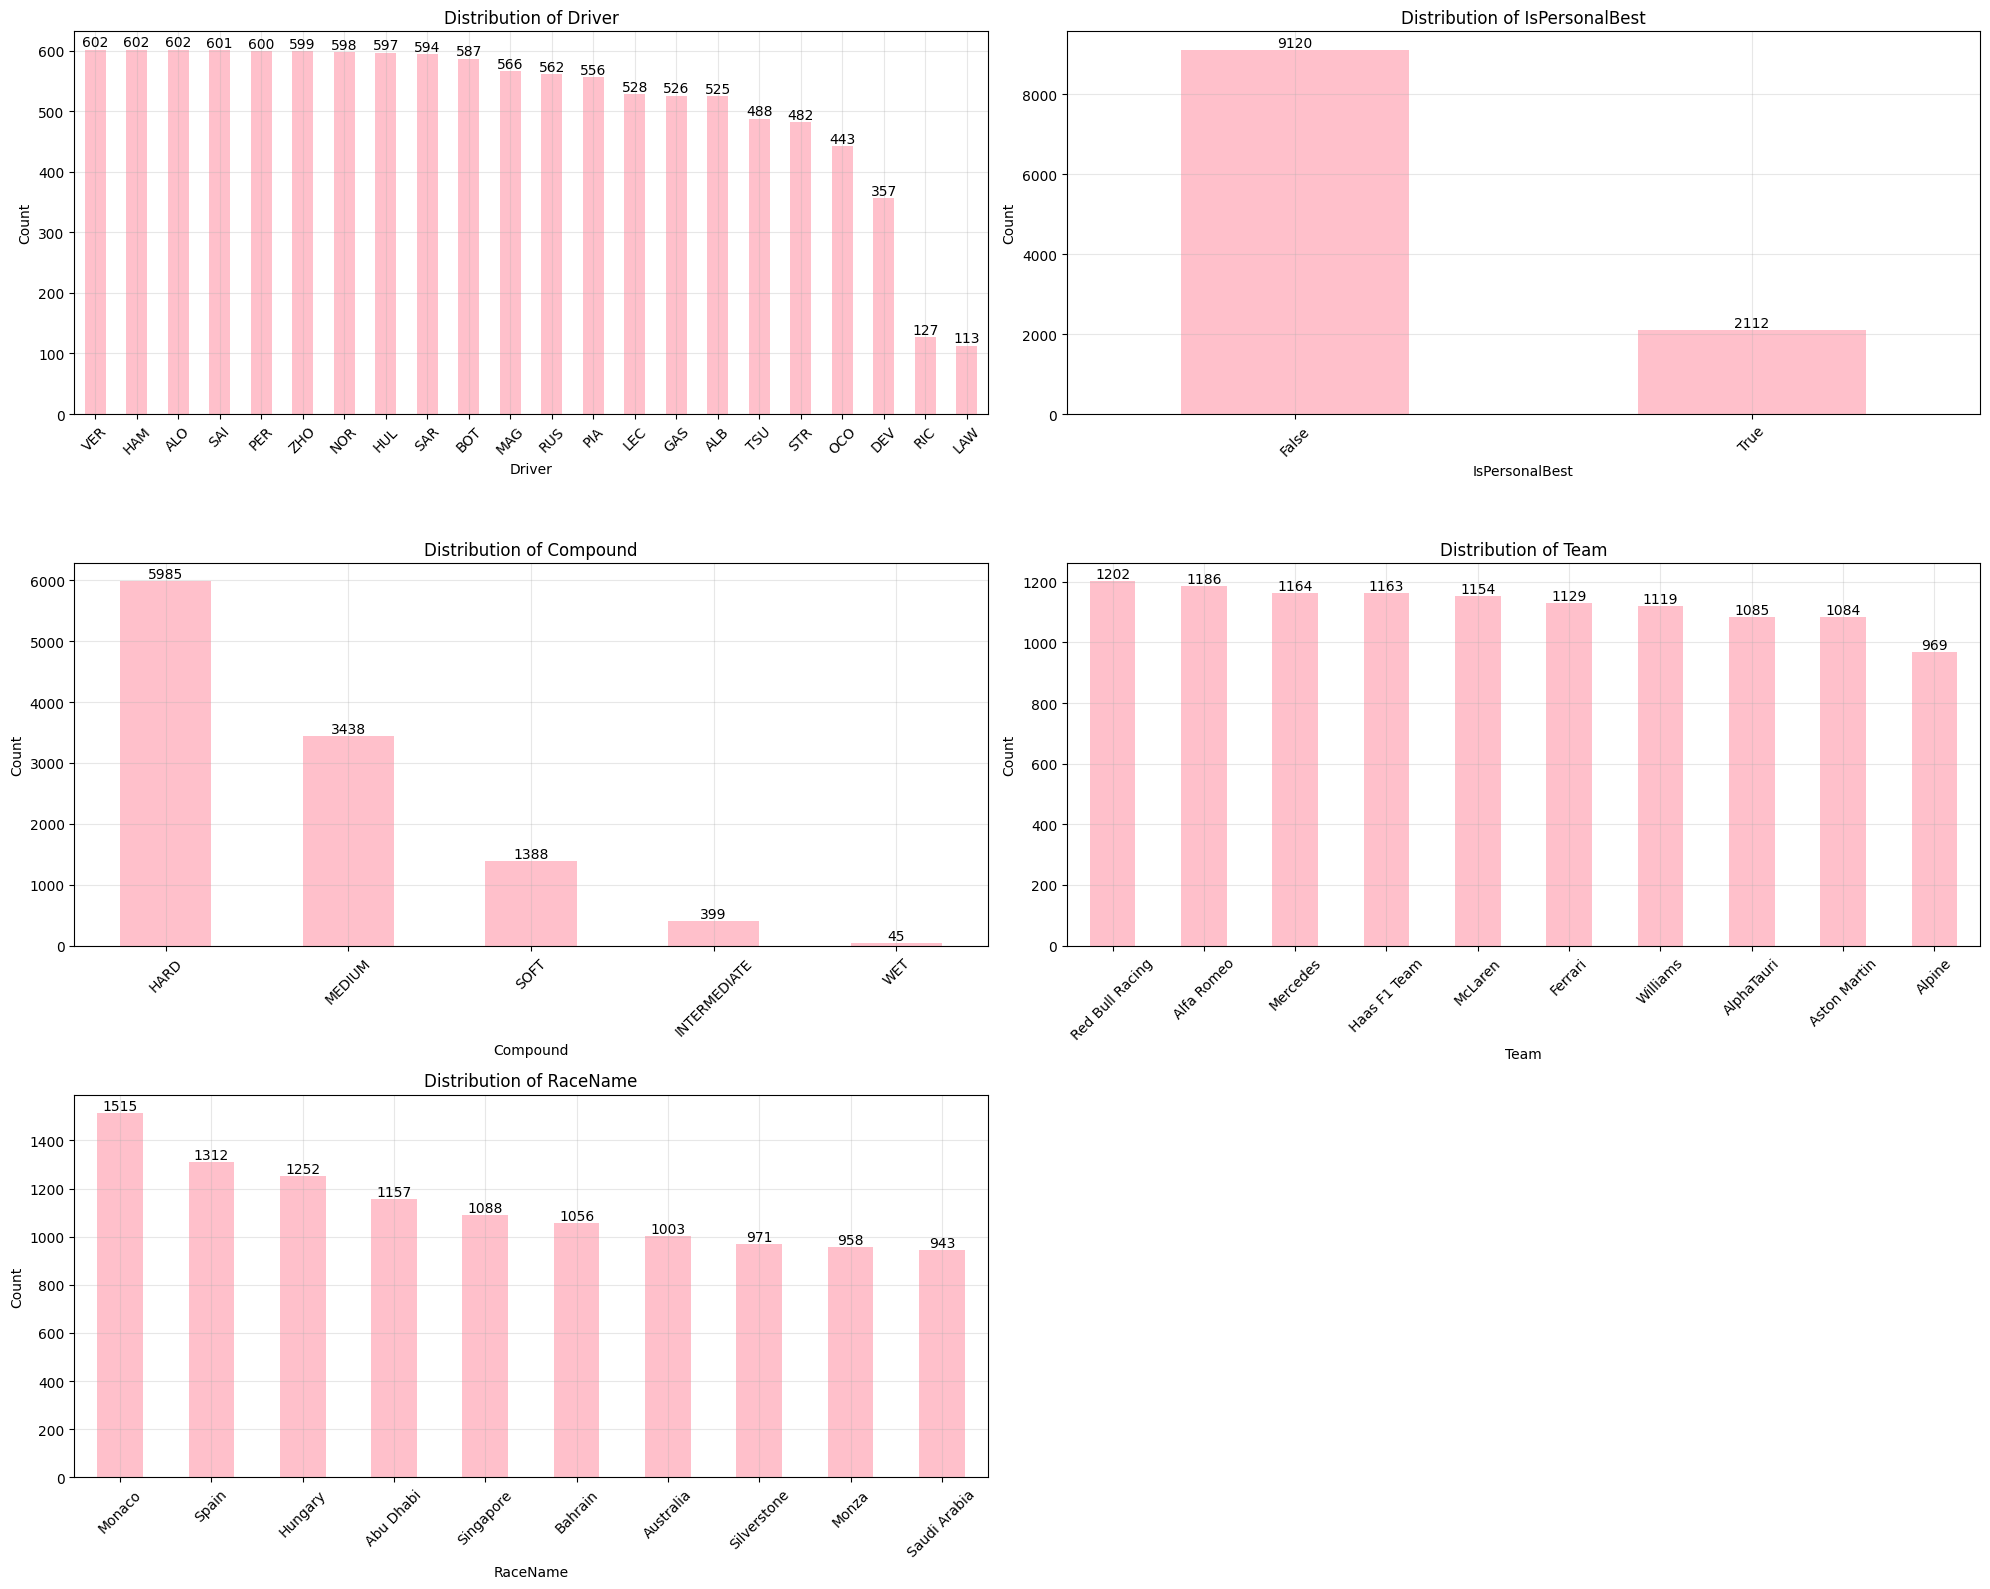

In [15]:
# Categorical cols visualization 

fig, axes = plt.subplots(3, 2, figsize = (20, 16))
axes = axes.flatten()

for i, feature in enumerate(categorical_features_01):
    df[feature].value_counts().plot(kind = "bar", ax = axes[i], color = "pink")
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis= "x", rotation = 45)
    axes[i].grid(True, alpha = 0.3)

    for patch in axes[i].patches:
        axes[i].text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + 0.3,
            int(patch.get_height()),
            ha='center', va='bottom', fontsize=10
        )


fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [16]:
# Drop columns (100% missing)
df.drop(columns =["LapStartDate", "Deleted","DeletedReason"], inplace = True)
df.head()


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,TrackStatus,Position,FastF1Generated,IsAccurate,RaceName,Year
0,0 days 01:04:15.902000,VER,1,0 days 00:01:39.019000,1.0,1.0,NaN,NaN,NaN,0 days 00:00:42.414000,0 days 00:00:23.842000,NaN,0 days 01:03:52.119000,0 days 01:04:16.010000,232.0,231.0,278.0,252.0,False,SOFT,4.0,False,Red Bull Racing,0 days 01:02:36.652000,12,1.0,False,False,Bahrain,2023
1,0 days 01:05:53.876000,VER,1,0 days 00:01:37.974000,2.0,1.0,NaN,NaN,0 days 00:00:31.342000,0 days 00:00:42.504000,0 days 00:00:24.128000,0 days 01:04:47.303000,0 days 01:05:29.807000,0 days 01:05:53.935000,227.0,238.0,278.0,288.0,True,SOFT,5.0,False,Red Bull Racing,0 days 01:04:15.902000,12,1.0,False,True,Bahrain,2023
2,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,NaN,NaN,0 days 00:00:31.388000,0 days 00:00:42.469000,0 days 00:00:24.149000,0 days 01:06:25.323000,0 days 01:07:07.792000,0 days 01:07:31.941000,227.0,238.0,278.0,287.0,False,SOFT,6.0,False,Red Bull Racing,0 days 01:05:53.876000,1,1.0,False,True,Bahrain,2023
3,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,NaN,NaN,0 days 00:00:31.271000,0 days 00:00:42.642000,0 days 00:00:24.063000,0 days 01:08:03.212000,0 days 01:08:45.854000,0 days 01:09:09.917000,228.0,238.0,278.0,289.0,False,SOFT,7.0,False,Red Bull Racing,0 days 01:07:31.882000,1,1.0,False,True,Bahrain,2023
4,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,NaN,NaN,0 days 00:00:31.244000,0 days 00:00:42.724000,0 days 00:00:24.067000,0 days 01:09:41.161000,0 days 01:10:23.885000,0 days 01:10:47.952000,228.0,239.0,278.0,290.0,False,SOFT,8.0,False,Red Bull Racing,0 days 01:09:09.858000,1,1.0,False,True,Bahrain,2023


- Assumption: A feature with 100% missing values carries zero information and can be safely removed.

In [17]:
print("df columns:", df.columns)
print(f"Shape of the dataset: {df.shape}")

df columns: Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'TrackStatus', 'Position', 'FastF1Generated', 'IsAccurate', 'RaceName',
       'Year'],
      dtype='object')
Shape of the dataset: (11255, 30)


In [18]:
# confirming the process ( missing columns are dropped)
missing_new = df.isnull().sum()
missing_pct_new = round((missing /len(df)) * 100, 3)

missing_df_new = pd.DataFrame({
    "missing_count": missing_new,
    "missing_pct(%)": missing_pct_new
}).sort_values("missing_pct(%)", ascending = False)

print(missing_df_new[missing_df_new["missing_count"]>0])

                    missing_count  missing_pct(%)
PitOutTime                10884.0          96.704
PitInTime                 10878.0          96.650
SpeedFL                     403.0           3.581
Sector1SessionTime          252.0           2.239
Sector1Time                 231.0           2.052
LapTime                     166.0           1.475
Sector3SessionTime           90.0           0.800
Sector3Time                  90.0           0.800
SpeedST                      27.0           0.240
SpeedI2                      26.0           0.231
SpeedI1                      26.0           0.231
Position                     26.0           0.231
Sector2SessionTime           26.0           0.231
Sector2Time                  26.0           0.231
IsPersonalBest               23.0           0.204


In [19]:
# Time-related cols
time_cols =[feature for feature in df.columns if ("Time" in feature) or ("Date"  in feature)]
print(time_cols)

['Time', 'LapTime', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'LapStartTime']


In [20]:
# Convert to timedelta --> seconds

# Strip column name incase of hidden spaces
df.columns = df.columns.str.strip()

# erros = "coerce" --> if you cannot convert a value, don't crash. replace it with NaN
for col in time_cols:
    df[col] = pd.to_timedelta(df[col], errors = "coerce").dt.total_seconds()

df[time_cols].head(20)

,Time,LapTime,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,LapStartTime
0,3855.902,99.019,NaN,NaN,NaN,42.414,23.842,NaN,3832.119,3856.010,3756.652
1,3953.876,97.974,NaN,NaN,31.342,42.504,24.128,3887.303,3929.807,3953.935,3855.902
2,4051.882,98.006,NaN,NaN,31.388,42.469,24.149,3985.323,4027.792,4051.941,3953.876
3,4149.858,97.976,NaN,NaN,31.271,42.642,24.063,4083.212,4125.854,4149.917,4051.882
4,4247.893,98.035,NaN,NaN,31.244,42.724,24.067,4181.161,4223.885,4247.952,4149.858
5,4345.879,97.986,NaN,NaN,31.341,42.632,24.013,4279.293,4321.925,4345.938,4247.893
6,4443.900,98.021,NaN,NaN,31.290,42.763,23.968,4377.228,4419.991,4443.959,4345.879
7,4542.054,98.154,NaN,NaN,31.291,42.833,24.030,4475.250,4518.083,4542.113,4443.900
8,4640.332,98.278,NaN,NaN,31.336,42.823,24.119,4573.449,4616.272,4640.391,4542.054
9,4738.701,98.369,NaN,NaN,31.361,42.884,24.124,4671.752,4714.636,4738.760,4640.332


In [23]:
df[time_cols].isna().sum()

Time                      0
LapTime                 166
PitOutTime            10884
PitInTime             10878
Sector1Time             231
Sector2Time              26
Sector3Time              90
Sector1SessionTime      252
Sector2SessionTime       26
Sector3SessionTime       90
LapStartTime              0
dtype: int64